# Customer Churn & Retention Analytics
## Notebook 1: Data Cleaning & Exploratory Data Analysis

This notebook performs data loading, data quality assessment, missing-value treatment,
data-type corrections, duplicate checks, descriptive statistics, and exploratory data analysis.

The target variable is **Churn**:
- 1 = Churned
- 0 = Retained

No machine learning or predictive modeling is performed in this notebook.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from datetime import datetime

# Suppress unnecessary warnings for a cleaner notebook
warnings.filterwarnings("ignore")

# Set pandas display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Set a professional visual style
sns.set_theme(style="darkgrid", context="notebook")

# Define the project color palette
CHURN_COLOR = "#E74C3C"
RETAINED_COLOR = "#2ECC71"
NEUTRAL_COLOR = "#3498DB"

# Create a common color palette for churn visualizations
CHURN_PALETTE = {
    "Churned": CHURN_COLOR,
    "Retained": RETAINED_COLOR
}

# Define project paths
RAW_FILE_PATH = "../data/raw/ecommerce_churn_raw.xlsx"
CLEANED_FILE_PATH = "../data/cleaned/cleaned_ecommerce_churn.csv"
IMAGE_FOLDER = "../reports/images"

# Create the output folders if they do not already exist
import os
os.makedirs("../data/cleaned", exist_ok=True)
os.makedirs(IMAGE_FOLDER, exist_ok=True)

# Print the analysis date
analysis_date = datetime.now().strftime("%Y-%m-%d")
print(f"Analysis Date: {analysis_date}")
print("Customer Churn & Retention Analytics - Notebook 1")

Analysis Date: 2026-08-30
Customer Churn & Retention Analytics - Notebook 1


## Section 2: Data Loading

This section loads the raw Excel workbook and confirms that the expected worksheet
and dataset are available.

We first inspect the workbook sheet names because the required data is stored
in the **E Comm** sheet.

In [2]:
# Load the Excel workbook
excel_workbook = pd.ExcelFile(RAW_FILE_PATH)

# Print all available sheet names
print("Available Excel Sheets:")
print(excel_workbook.sheet_names)

# Load the required E Comm sheet
df = pd.read_excel(RAW_FILE_PATH, sheet_name="E Comm")

print("\nDataset loaded successfully.")

Available Excel Sheets:
['Data Dict', 'E Comm']

Dataset loaded successfully.


### Dataset Overview

This cell checks the basic structure of the dataset before cleaning.

The checks include:
- Number of rows and columns
- Memory usage
- Number of duplicated rows
- Number of duplicated Customer IDs

This gives us an initial understanding of data quality.

In [3]:
# Display the basic dataset dimensions
print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]:,}")

# Display memory usage
memory_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory Usage: {memory_usage_mb:.2f} MB")

# Check for complete duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows:,}")

# Check for duplicate Customer IDs
duplicate_customer_ids = df["CustomerID"].duplicated().sum()
print(f"Duplicate Customer IDs: {duplicate_customer_ids:,}")

# Display the first five records
print("\nFirst 5 Rows:")
display(df.head())

Number of Rows: 5,630
Number of Columns: 20
Memory Usage: 2.18 MB
Duplicate Rows: 0
Duplicate Customer IDs: 0

First 5 Rows:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.00,Mobile Phone,3,6.00,s,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


### Data Types and Structure

`df.info()` provides a detailed overview of every column, including:
- Data type
- Number of non-null values
- Memory usage

This is important because incorrect data types can cause problems during analysis
and visualization.

In [4]:
# Display the complete dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

## Section 3: Data Quality Report

A data quality report gives us a column-by-column view of the dataset.

For every column, we calculate:
- Data Type
- Non-Null Count
- Null Count
- Null Percentage
- Number of Unique Values
- Sample Value

This helps identify missing data and possible data-type issues before cleaning.

In [5]:
# Create a reusable function for generating the data quality report
def create_data_quality_report(dataframe):
    quality_records = []

    for column in dataframe.columns:
        quality_records.append({
            "Column": column,
            "Data Type": str(dataframe[column].dtype),
            "Non-Null Count": dataframe[column].notna().sum(),
            "Null Count": dataframe[column].isna().sum(),
            "Null %": round(dataframe[column].isna().mean() * 100, 2),
            "Unique Values": dataframe[column].nunique(dropna=True),
            "Sample Value": dataframe[column].dropna().iloc[0]
                if dataframe[column].notna().any() else np.nan
        })

    # Convert the list of records into a dataframe
    quality_report = pd.DataFrame(quality_records)

    return quality_report


# Generate the data quality report
quality_report = create_data_quality_report(df)

# Display the report
display(quality_report)

,Column,Data Type,Non-Null Count,Null Count,Null %,Unique Values,Sample Value
0,CustomerID,int64,5630,0,0.00,5630,50001
1,Churn,int64,5630,0,0.00,2,1
2,Tenure,float64,5366,264,4.69,36,4.00
3,PreferredLoginDevice,object,5630,0,0.00,3,Mobile Phone
4,CityTier,int64,5630,0,0.00,3,3
5,WarehouseToHome,float64,5379,251,4.46,34,6.00
6,PreferredPaymentMode,object,5630,0,0.00,8,s
7,Gender,object,5630,0,0.00,2,Female
8,HourSpendOnApp,float64,5375,255,4.53,6,3.00
9,NumberOfDeviceRegistered,int64,5630,0,0.00,6,3


## Section 4: Missing Value Treatment

First, we calculate the number and percentage of missing values in every column.

Understanding the missing-value pattern is important before deciding how to treat
NULL values.

In [6]:
# Calculate missing-value count and percentage
missing_value_report = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

# Keep only columns containing missing values
missing_value_report = missing_value_report[
    missing_value_report["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

# Display missing-value information
display(missing_value_report)

,Missing Count,Missing %
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


### Missing Value Visualization

This bar chart shows which columns contain missing values and how many records
are affected.

The visualization makes it easier to identify the columns requiring treatment.

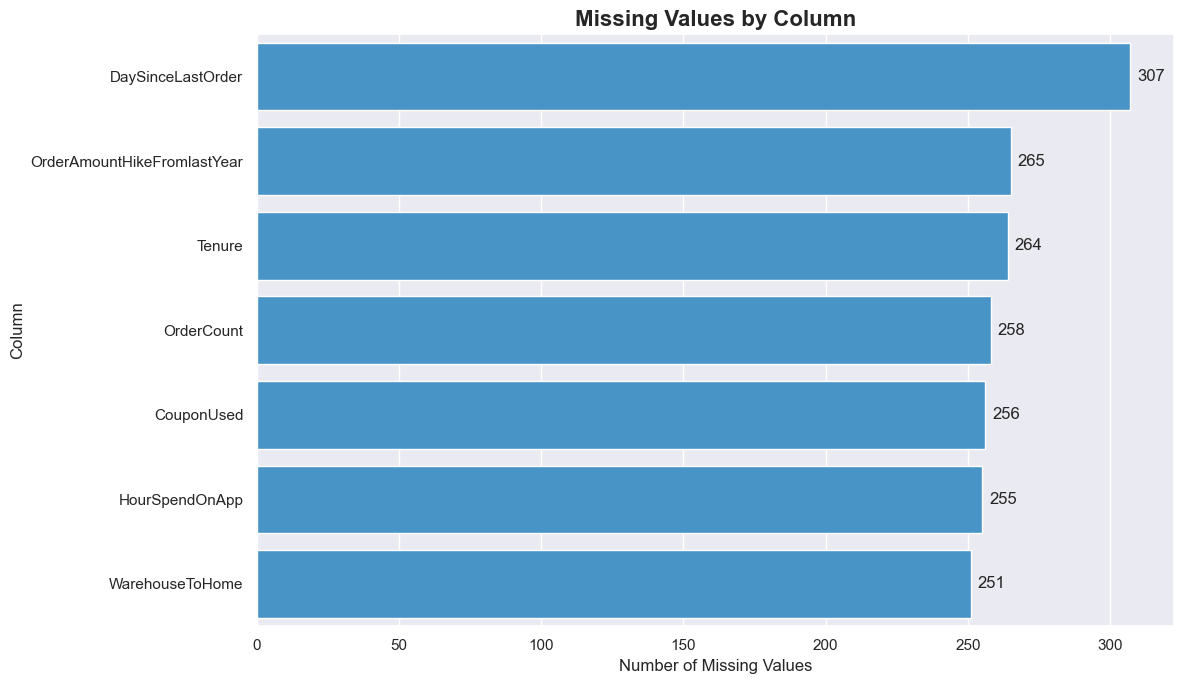

In [7]:
# Create a missing-value bar chart
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=missing_value_report["Missing Count"],
    y=missing_value_report.index,
    color=NEUTRAL_COLOR
)

# Add count labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=5)

plt.title("Missing Values by Column", fontsize=16, fontweight="bold")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.tight_layout()

# Save the chart
plt.savefig(
    f"{IMAGE_FOLDER}/01_missing_values.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Missing Value Treatment Strategy

The missing values are numerical variables, so they will be filled using the
**median** of each respective column.

Median is preferred over mean because it is more robust to extreme values and
outliers.

We will not remove rows because doing so would unnecessarily reduce the number
of customers available for analysis.

In [8]:
# Identify numerical columns containing missing values
numerical_columns_with_nulls = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder"
]

# Store median values before filling NULLs
median_values_used = {}

# Fill each numerical NULL with its column median
for column in numerical_columns_with_nulls:
    median_value = df[column].median()
    median_values_used[column] = median_value

    # Fill missing values using the median
    df[column] = df[column].fillna(median_value)

# Display the median values used for treatment
median_report = pd.DataFrame(
    list(median_values_used.items()),
    columns=["Column", "Median Used"]
)

print("Median values used for missing-value treatment:")
display(median_report)

# Verify that all NULL values have been removed
remaining_nulls = df.isna().sum().sum()

print(f"Total remaining NULL values: {remaining_nulls}")

if remaining_nulls == 0:
    print("SUCCESS: No NULL values remain after treatment.")
else:
    print("WARNING: Some NULL values still remain.")

Median values used for missing-value treatment:


,Column,Median Used
0,Tenure,9.00
1,WarehouseToHome,14.00
2,HourSpendOnApp,3.00
3,OrderAmountHikeFromlastYear,15.00
4,CouponUsed,1.00
5,OrderCount,2.00
6,DaySinceLastOrder,3.00


Total remaining NULL values: 0
SUCCESS: No NULL values remain after treatment.


## Section 5: Data Type Corrections

Some columns are numerically stored but are actually categorical variables.

For example, **CityTier** contains categories such as 1, 2, and 3 rather than
continuous numerical measurements.

We therefore convert:
- CityTier → category
- Churn → keep numeric and create a separate ChurnLabel
- Complain → create a readable categorical label

Keeping the original numeric Churn column is important for later analysis.

In [9]:
# Display the current data types before corrections
print("Data types before correction:")
display(df.dtypes)

Data types before correction:


CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

### Apply Data Type Corrections

This cell applies the required corrections while preserving the original
numeric Churn column.

The new `ChurnLabel` column is used for human-readable visualizations.

In [10]:
# Convert CityTier from numeric values to categorical values
df["CityTier"] = df["CityTier"].astype("category")

# Create a readable churn label while keeping numeric Churn unchanged
df["ChurnLabel"] = df["Churn"].map({
    0: "Retained",
    1: "Churned"
})

# Create a readable complaint label
df["ComplainLabel"] = df["Complain"].map({
    0: "No Complaint",
    1: "Complaint"
})

# Display corrected data types
print("Data types after correction:")
display(df.dtypes)

# Display the new label columns
display(df[["Churn", "ChurnLabel", "Complain", "ComplainLabel"]].head())

Data types after correction:


CustomerID                        int64
Churn                             int64
Tenure                          float64
PreferredLoginDevice             object
CityTier                       category
WarehouseToHome                 float64
PreferredPaymentMode             object
Gender                           object
HourSpendOnApp                  float64
NumberOfDeviceRegistered          int64
PreferedOrderCat                 object
SatisfactionScore                 int64
MaritalStatus                    object
NumberOfAddress                   int64
Complain                          int64
OrderAmountHikeFromlastYear     float64
CouponUsed                      float64
OrderCount                      float64
DaySinceLastOrder               float64
CashbackAmount                  float64
ChurnLabel                       object
ComplainLabel                    object
dtype: object

,Churn,ChurnLabel,Complain,ComplainLabel
0,1,Churned,1,Complaint
1,1,Churned,1,Complaint
2,1,Churned,1,Complaint
3,1,Churned,0,No Complaint
4,1,Churned,0,No Complaint


In [11]:
# ============================================================
# STANDARDIZE CATEGORICAL VALUES
# ============================================================

# Preferred Payment Mode
df["PreferredPaymentMode"] = (
    df["PreferredPaymentMode"]
    .astype(str)
    .str.strip()
)

df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "COD": "Cash on Delivery",
    "s": "Cash on Delivery",
    "S": "Cash on Delivery"
})


# Preferred Order Category
df["PreferedOrderCat"] = (
    df["PreferedOrderCat"]
    .astype(str)
    .str.strip()
)

df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({
    "Mobile Phone": "Mobile"
})


# Verify
print("Payment Modes:")
print(df["PreferredPaymentMode"].value_counts())

print("\nOrder Categories:")
print(df["PreferedOrderCat"].value_counts())

Payment Modes:
PreferredPaymentMode
Debit Card          2313
Credit Card         1501
E wallet             614
Cash on Delivery     515
UPI                  414
CC                   273
Name: count, dtype: int64

Order Categories:
PreferedOrderCat
Mobile                2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


## Section 6: Duplicate Check

CustomerID should uniquely identify each customer.

We check for duplicate CustomerIDs and remove duplicate customer records if
they exist.

This prevents a customer from being counted multiple times in retention and
churn calculations.
    

In [12]:
# Count duplicate Customer IDs
duplicate_customer_count = df["CustomerID"].duplicated().sum()

print(f"Duplicate Customer IDs found: {duplicate_customer_count}")

if duplicate_customer_count > 0:
    # Keep the first record when duplicate Customer IDs are found
    df = df.drop_duplicates(subset="CustomerID", keep="first").copy()

    print("Duplicate CustomerID records were removed.")
else:
    print("No duplicate CustomerIDs found. Dataset is ready for analysis.")

# Display the resulting dataset shape
print(f"Dataset shape after duplicate check: {df.shape}")

Duplicate Customer IDs found: 0
No duplicate CustomerIDs found. Dataset is ready for analysis.
Dataset shape after duplicate check: (5630, 22)


## Section 7: Descriptive Statistics

Descriptive statistics help us understand the central tendency, spread, and
distribution of numerical variables.

For categorical variables, we inspect counts and the number of unique categories.

In [13]:
# Display descriptive statistics for numerical columns
print("Numerical Descriptive Statistics:")
display(df.describe())

Numerical Descriptive Statistics:


,CustomerID,Churn,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,"5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00","5,630.00"
mean,"52,815.50",0.17,10.13,15.57,2.93,3.69,3.07,4.21,0.28,15.67,1.72,2.96,4.46,177.22
std,"1,625.39",0.37,8.36,8.35,0.71,1.02,1.38,2.58,0.45,3.59,1.86,2.88,3.57,49.21
min,"50,001.00",0.00,0.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,"51,408.25",0.00,3.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,145.77
50%,"52,815.50",0.00,9.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.28
75%,"54,222.75",0.00,15.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.39
max,"55,630.00",1.00,61.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,324.99


### Categorical Descriptive Statistics

This section summarizes categorical variables.

The output shows the number of non-null records, number of unique categories,
most frequent category, and its frequency.

In [14]:
# Select categorical columns for descriptive analysis
categorical_columns = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
    "CityTier",
    "ChurnLabel",
    "ComplainLabel"
]

# Display categorical descriptive statistics
display(df[categorical_columns].describe())

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,CityTier,ChurnLabel,ComplainLabel
count,5630,5630,5630,5630,5630,5630,5630,5630
unique,3,6,2,5,3,3,2,2
top,Mobile Phone,Debit Card,Male,Mobile,Married,1,Retained,No Complaint
freq,2765,2313,3384,2080,2986,3666,4682,4026


### Churn Distribution

The target variable is analyzed using both count and percentage.

This provides the baseline churn rate that will be used throughout the project.

In [15]:
# Calculate churn counts
churn_counts = df["Churn"].value_counts().sort_index()

# Calculate churn percentages
churn_percentages = (
    df["Churn"].value_counts(normalize=True).sort_index() * 100
).round(2)

# Create a summary table
churn_summary = pd.DataFrame({
    "Status": ["Retained", "Churned"],
    "Count": [
        churn_counts.get(0, 0),
        churn_counts.get(1, 0)
    ],
    "Percentage": [
        churn_percentages.get(0, 0),
        churn_percentages.get(1, 0)
    ]
})

display(churn_summary)

,Status,Count,Percentage
0,Retained,4682,83.16
1,Churned,948,16.84


## Section 8: Univariate Analysis — Target Variable

The target variable is visualized using both a pie chart and a bar chart.

The pie chart shows the overall proportion of retained and churned customers,
while the bar chart shows the exact customer counts.

Both charts display count and percentage information.

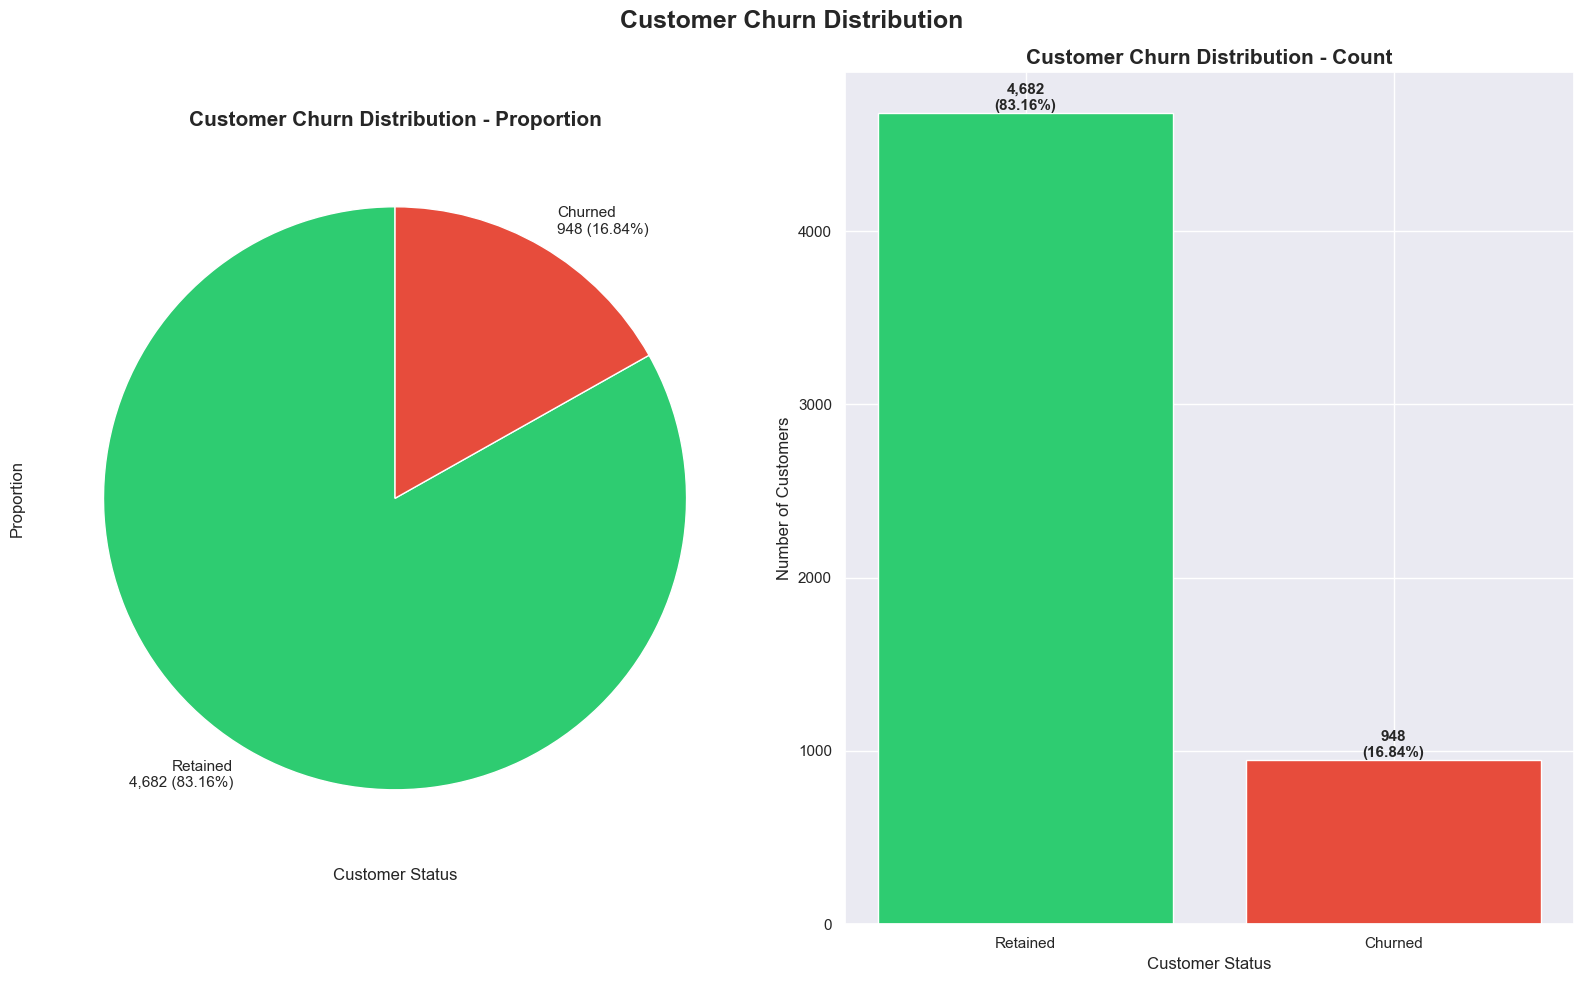

In [16]:
# Prepare churn labels and values
churn_labels = ["Retained", "Churned"]
churn_values = [
    df["Churn"].eq(0).sum(),
    df["Churn"].eq(1).sum()
]

churn_colors = [RETAINED_COLOR, CHURN_COLOR]

# Calculate percentages
churn_total = sum(churn_values)
churn_rates = [
    value / churn_total * 100 for value in churn_values
]

# Create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# -------------------- Pie Chart --------------------
axes[0].pie(
    churn_values,
    labels=[
        f"Retained\n{churn_values[0]:,} ({churn_rates[0]:.2f}%)",
        f"Churned\n{churn_values[1]:,} ({churn_rates[1]:.2f}%)"
    ],
    colors=churn_colors,
    autopct=None,
    startangle=90,
    textprops={"fontsize": 11}
)

axes[0].set_title(
    "Customer Churn Distribution - Proportion",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Customer Status")
axes[0].set_ylabel("Proportion")

# -------------------- Bar Chart --------------------
bars = axes[1].bar(
    churn_labels,
    churn_values,
    color=churn_colors
)

# Add count and percentage labels
for bar, count, percentage in zip(bars, churn_values, churn_rates):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

axes[1].set_title(
    "Customer Churn Distribution - Count",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Customer Status")
axes[1].set_ylabel("Number of Customers")

plt.suptitle(
    "Customer Churn Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save the combined target distribution chart
plt.savefig(
    f"{IMAGE_FOLDER}/02_customer_churn_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 9: Univariate Analysis — Numerical Columns

This section analyzes every important numerical customer behavior variable.

For each variable we display:
- Histogram — shows the distribution of values
- Boxplot — shows spread and potential outliers

A 3-column variable layout is used to keep the analysis compact and readable.

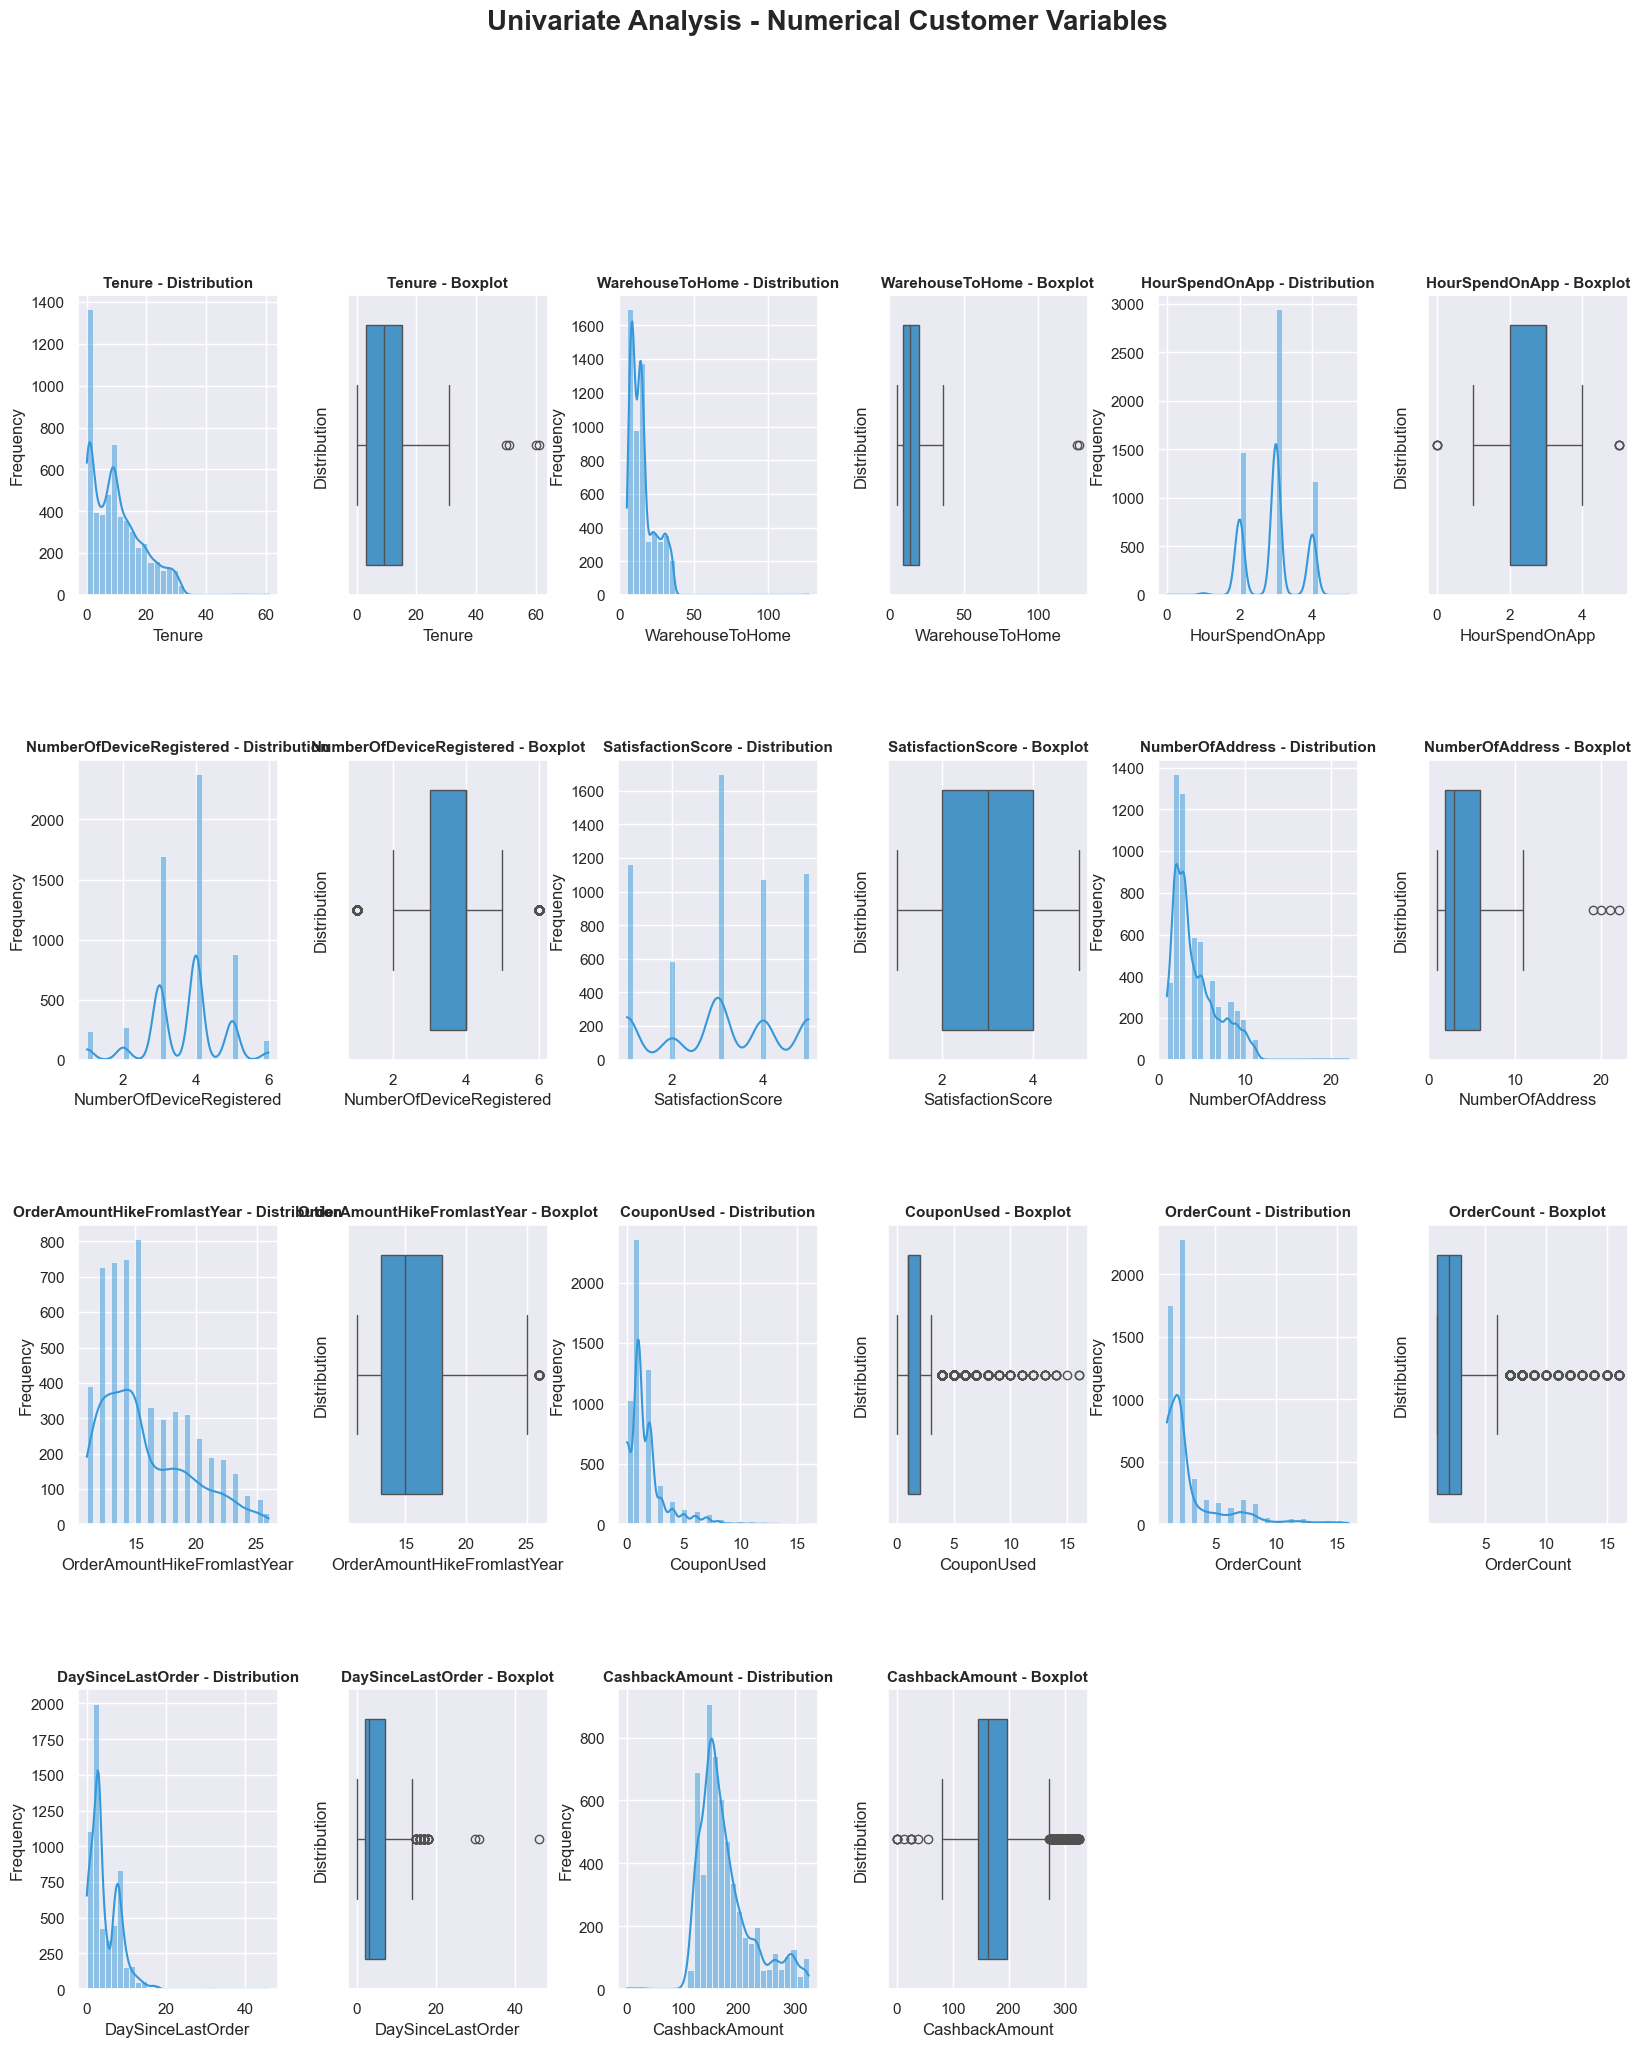

In [17]:
# Define the numerical columns required for univariate analysis
numerical_analysis_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

# Define the number of variables per row
variables_per_row = 3

# Calculate the required number of rows
number_of_rows = int(
    np.ceil(len(numerical_analysis_columns) / variables_per_row)
)

# Create a figure with 6 columns:
# Each variable gets two columns: histogram + boxplot
fig = plt.figure(
    figsize=(20, number_of_rows * 5.5)
)

grid = fig.add_gridspec(
    number_of_rows,
    variables_per_row * 2,
    hspace=0.55,
    wspace=0.35
)

# Loop through every numerical column
for index, column in enumerate(numerical_analysis_columns):

    # Determine the variable's row and column position
    row_position = index // variables_per_row
    variable_position = index % variables_per_row

    histogram_axis = fig.add_subplot(
        grid[row_position, variable_position * 2]
    )

    boxplot_axis = fig.add_subplot(
        grid[row_position, variable_position * 2 + 1]
    )

    # -------------------- Histogram --------------------
    sns.histplot(
        df[column],
        bins=30,
        kde=True,
        color=NEUTRAL_COLOR,
        ax=histogram_axis
    )

    histogram_axis.set_title(
        f"{column} - Distribution",
        fontsize=11,
        fontweight="bold"
    )

    histogram_axis.set_xlabel(column)
    histogram_axis.set_ylabel("Frequency")

    # -------------------- Boxplot --------------------
    sns.boxplot(
        x=df[column],
        color=NEUTRAL_COLOR,
        ax=boxplot_axis
    )

    boxplot_axis.set_title(
        f"{column} - Boxplot",
        fontsize=11,
        fontweight="bold"
    )

    boxplot_axis.set_xlabel(column)
    boxplot_axis.set_ylabel("Distribution")

# Add an overall figure title
fig.suptitle(
    "Univariate Analysis - Numerical Customer Variables",
    fontsize=20,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

# Save the numerical analysis chart
plt.savefig(
    f"{IMAGE_FOLDER}/03_numerical_univariate_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 10: Univariate Analysis — Categorical Columns

This section analyzes the distribution of the main categorical customer
attributes.

The selected variables are:
- PreferredLoginDevice
- PreferredPaymentMode
- Gender
- PreferedOrderCat
- MaritalStatus
- CityTier

Count labels are displayed above each bar so that the chart can be interpreted
without referring back to a table.

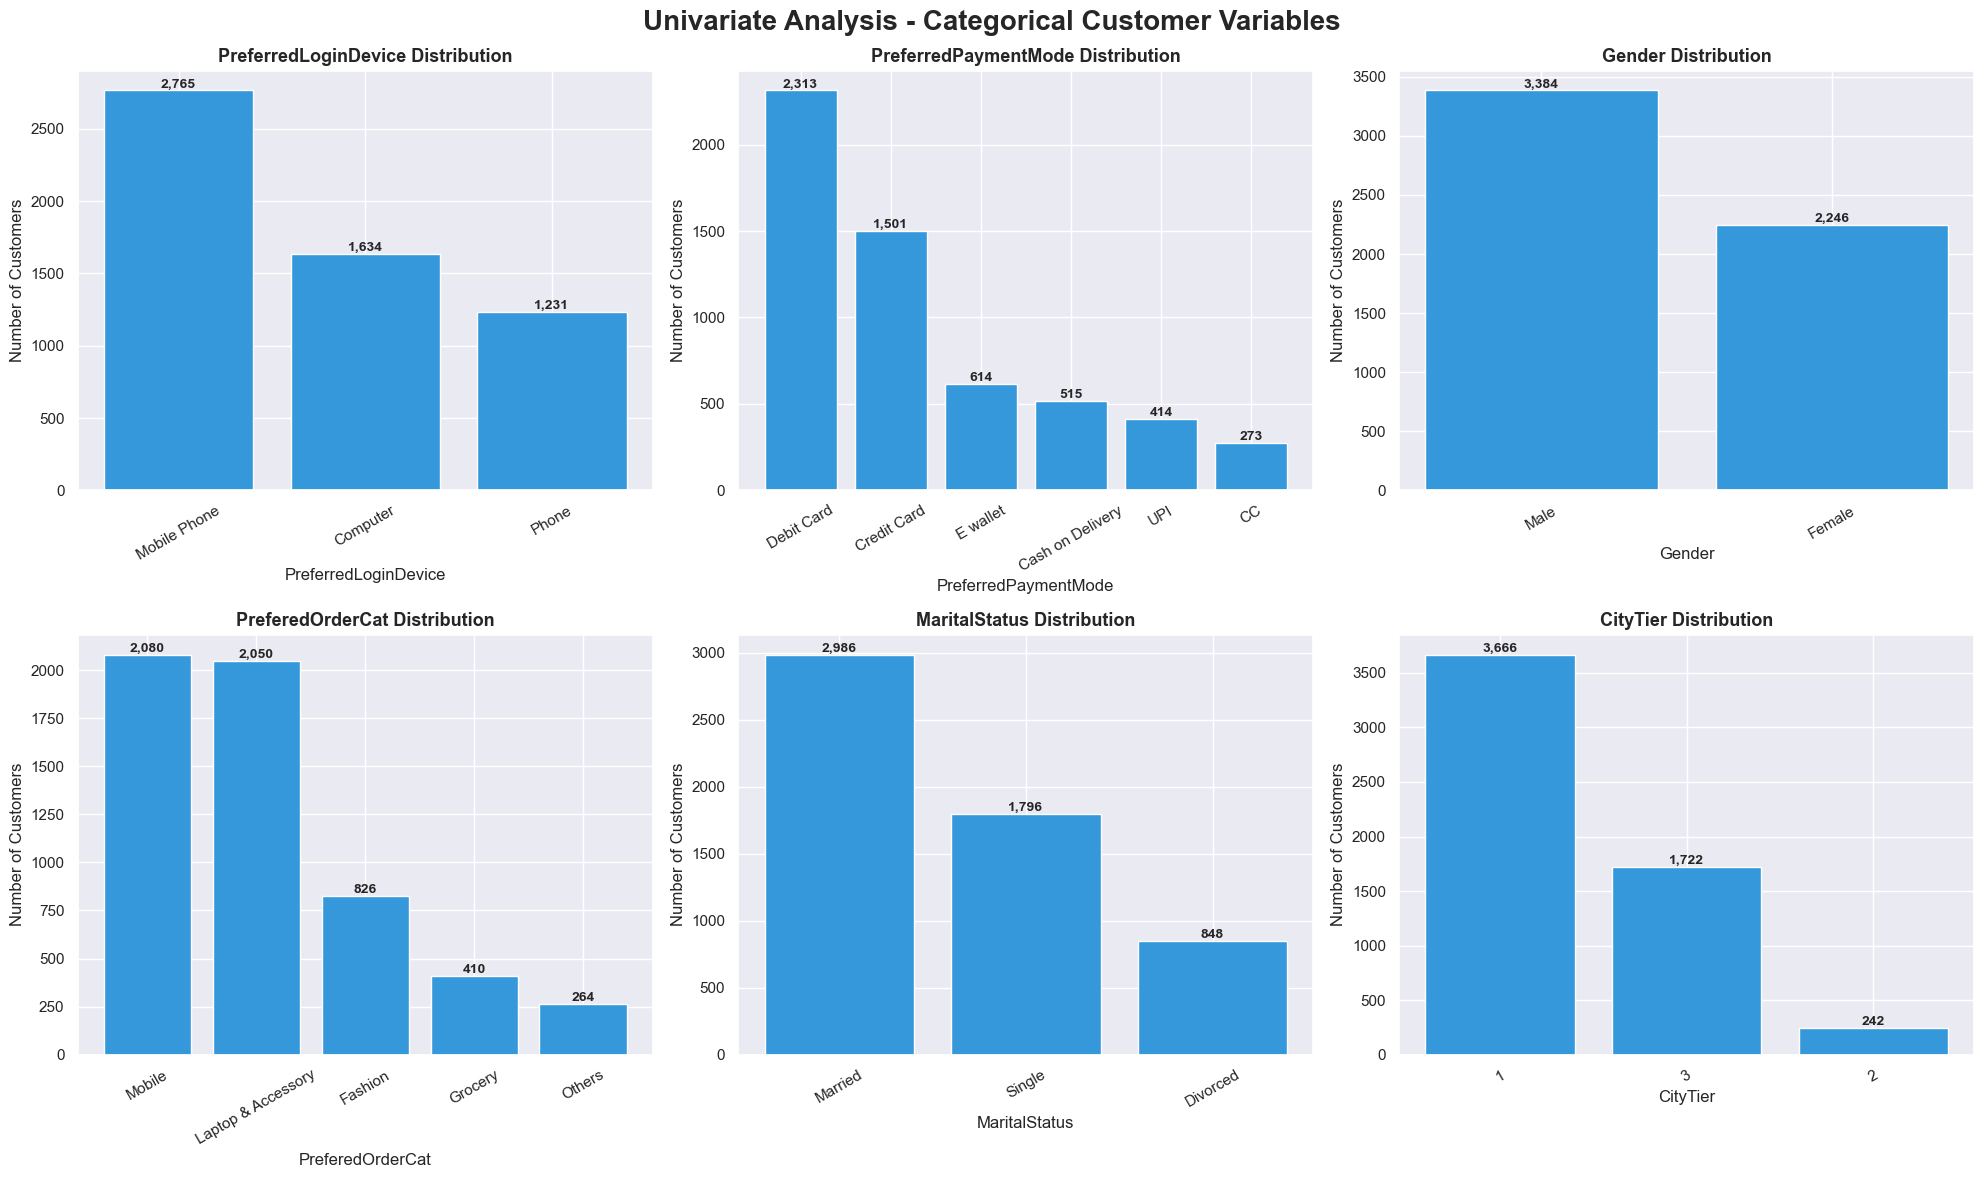

In [18]:
# Define categorical columns for univariate analysis
categorical_analysis_columns = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
    "CityTier"
]

# Create a 2 x 3 subplot layout
fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 12)
)

# Flatten axes for easier iteration
axes = axes.flatten()

# Create a neutral color palette
categorical_color = NEUTRAL_COLOR

# Loop through each categorical variable
for index, column in enumerate(categorical_analysis_columns):

    # Calculate category counts
    category_counts = df[column].value_counts()

    # Convert category names to strings for consistent plotting
    category_labels = category_counts.index.astype(str)

    # Create the bar chart
    bars = axes[index].bar(
        category_labels,
        category_counts.values,
        color=categorical_color
    )

    # Add count labels above each bar
    for bar in bars:
        height = bar.get_height()

        axes[index].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    # Configure chart title and axes
    axes[index].set_title(
        f"{column} Distribution",
        fontsize=13,
        fontweight="bold"
    )

    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Number of Customers")

    # Rotate labels when category names are long
    axes[index].tick_params(axis="x", rotation=30)

# Add overall title
fig.suptitle(
    "Univariate Analysis - Categorical Customer Variables",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

# Save the categorical analysis chart
plt.savefig(
    f"{IMAGE_FOLDER}/04_categorical_univariate_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 11: Overall Churn Rate KPI Display

This section presents the most important business KPI from the initial EDA.

The KPI summarizes:
- Total customers
- Retained customers
- Churned customers
- Overall churn rate

These numbers provide the baseline for the later retention analysis.

In [19]:
# Calculate the main churn KPIs
total_customers = len(df)
retained_customers = (df["Churn"] == 0).sum()
churned_customers = (df["Churn"] == 1).sum()

retained_percentage = retained_customers / total_customers * 100
churn_percentage = churned_customers / total_customers * 100

# Print a formatted KPI box
print("=" * 60)
print("          CUSTOMER CHURN & RETENTION KPI")
print("=" * 60)
print(f"Total Customers : {total_customers:>10,}")
print(
    f"Retained        : {retained_customers:>10,} "
    f"({retained_percentage:.2f}%)"
)
print(
    f"Churned         : {churned_customers:>10,} "
    f"({churn_percentage:.2f}%)"
)
print(f"Churn Rate      : {churn_percentage:>10.2f}%")
print("=" * 60)

          CUSTOMER CHURN & RETENTION KPI
Total Customers :      5,630
Retained        :      4,682 (83.16%)
Churned         :        948 (16.84%)
Churn Rate      :      16.84%


## Section 12: Export Cleaned Data

The cleaned dataset is exported as a CSV file.

The exported dataset contains:
- Missing values treated using median imputation
- Corrected categorical data types
- ChurnLabel for readable analysis
- ComplainLabel for readable analysis
- Duplicate CustomerIDs removed if any existed

This cleaned dataset can be used in the next stages of the project.

In [20]:
# Create a separate dataframe for the final cleaned dataset
df_cleaned = df.copy()

# Export the cleaned dataframe as CSV
df_cleaned.to_csv(
    CLEANED_FILE_PATH,
    index=False
)

# Confirm the exported file
print("Cleaned dataset exported successfully.")
print(f"File Path : {CLEANED_FILE_PATH}")
print(f"Shape     : {df_cleaned.shape}")

# Print the final column list
print("\nCleaned Data Columns:")
for column_number, column_name in enumerate(df_cleaned.columns, start=1):
    print(f"{column_number:02d}. {column_name}")

Cleaned dataset exported successfully.
File Path : ../data/cleaned/cleaned_ecommerce_churn.csv
Shape     : (5630, 22)

Cleaned Data Columns:
01. CustomerID
02. Churn
03. Tenure
04. PreferredLoginDevice
05. CityTier
06. WarehouseToHome
07. PreferredPaymentMode
08. Gender
09. HourSpendOnApp
10. NumberOfDeviceRegistered
11. PreferedOrderCat
12. SatisfactionScore
13. MaritalStatus
14. NumberOfAddress
15. Complain
16. OrderAmountHikeFromlastYear
17. CouponUsed
18. OrderCount
19. DaySinceLastOrder
20. CashbackAmount
21. ChurnLabel
22. ComplainLabel


## Section 13: Key Observations Summary

The final section summarizes the main findings from the initial EDA.

These observations are descriptive rather than predictive. They will help define
business questions for the next stage of the Customer Churn & Retention project.

In [21]:
# Calculate a few supporting statistics for the observation summary
most_common_city_tier = df["CityTier"].value_counts().idxmax()
most_common_login_device = df["PreferredLoginDevice"].value_counts().idxmax()
most_common_order_category = df["PreferedOrderCat"].value_counts().idxmax()
most_common_gender = df["Gender"].value_counts().idxmax()

# Calculate complaint-based churn rates
complaint_churn_rate = (
    df.loc[df["Complain"] == 1, "Churn"].mean() * 100
)

no_complaint_churn_rate = (
    df.loc[df["Complain"] == 0, "Churn"].mean() * 100
)

# Print the key observations
print("=" * 75)
print("                    KEY EDA OBSERVATIONS")
print("=" * 75)

print(
    f"1. The dataset contains {total_customers:,} customers, "
    f"with an overall churn rate of {churn_percentage:.2f}%."
)

print(
    f"2. Retained customers represent {retained_percentage:.2f}% "
    f"of the customer base, while churned customers represent "
    f"{churn_percentage:.2f}%."
)

print(
    f"3. City Tier {most_common_city_tier} has the largest customer "
    f"population, indicating that the customer base is concentrated "
    f"in this city tier."
)

print(
    f"4. {most_common_gender} customers form the larger share of the "
    f"customer base."
)

print(
    f"5. {most_common_login_device} is the most commonly preferred "
    f"login device among customers."
)

print(
    f"6. {most_common_order_category} is the most frequently selected "
    f"preferred order category."
)

print(
    f"7. Customers who submitted a complaint show a churn rate of "
    f"{complaint_churn_rate:.2f}%, compared with "
    f"{no_complaint_churn_rate:.2f}% among customers without a complaint. "
    f"This suggests that customer complaints deserve deeper investigation "
    f"in the retention analysis."
)

print("=" * 75)
print("EDA completed successfully.")

                    KEY EDA OBSERVATIONS
1. The dataset contains 5,630 customers, with an overall churn rate of 16.84%.
2. Retained customers represent 83.16% of the customer base, while churned customers represent 16.84%.
3. City Tier 1 has the largest customer population, indicating that the customer base is concentrated in this city tier.
4. Male customers form the larger share of the customer base.
5. Mobile Phone is the most commonly preferred login device among customers.
6. Mobile is the most frequently selected preferred order category.
7. Customers who submitted a complaint show a churn rate of 31.67%, compared with 10.93% among customers without a complaint. This suggests that customer complaints deserve deeper investigation in the retention analysis.
EDA completed successfully.
